# Derived_Variable — 1st 단일 소스 파생변수 + 선택적 차분

**데이터**: `EDA_1st_result.csv` (level, 결측치 채움)

| 단계 | 내용 |
|------|------|
| 1 | 1st 데이터 로드 (level) |
| 2 | 1st 위에서 모든 파생변수 생성 |
| 3 | (1st 베이스 + 파생변수) 통합 → ADF 기반 선택적 1차 차분 |
| 4 | 결측치 / 정상성(ADF) / 다중공선성(VIF) 검정 |
| 5 | `Derived_Variable_test.csv` 저장 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── EDA_1st_result 로드 (level, 결측치 처리 완료) ──────────
LEVEL_PATH = '../data/Finance_Final/EDA_1st_result.csv'
df_lvl = (
    pd.read_csv(LEVEL_PATH, parse_dates=['date'])
      .sort_values('date')                # 날짜 오름차순 (데이터 누수 방지)
      .set_index('date')
)

print(f'1st (level) shape : {df_lvl.shape}')
print(f'기간               : {df_lvl.index.min().date()} ~ {df_lvl.index.max().date()}')
print(f'정렬 (asc)        : {df_lvl.index.is_monotonic_increasing}')
print(f'중복 날짜         : {df_lvl.index.duplicated().sum()}')
print(f'결측치            : {df_lvl.isnull().sum().to_dict()}')
print(f'\n컬럼 ({len(df_lvl.columns)}개): {df_lvl.columns.tolist()}')
display(df_lvl.head(3))

1st (level) shape : (4820, 13)
기간               : 2007-01-02 ~ 2026-03-16
정렬 (asc)        : True
중복 날짜         : 0
결측치            : {'OilPrice': 0, 'RealInterestRate': 0, 'CPI': 0, 'DollarIndex': 0, 'VIX': 0, 'IndustryProduction': 0, 'CPE': 0, 'OilInventories': 0, 'OPECProduction': 0, 'OilProduction': 0, 'TermSpread': 0, 'TreasuryYield': 0, 'FedFundsRate': 0}

컬럼 (13개): ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']


,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TermSpread,TreasuryYield,FedFundsRate
date,,,,,,,,,,,,,
2007-01-02,60.77,2.148076,203.437,97.0323,11.56,99.8346,11181.0,303219.0,32670.334,5369.0,-0.12,4.68,5.25
2007-01-03,58.31,2.148076,203.437,97.1281,12.04,99.8346,11181.0,303219.0,32670.334,5369.0,-0.09,4.67,5.25
2007-01-04,55.65,2.148076,203.437,97.5251,11.51,99.8346,11181.0,303219.0,32670.334,5369.0,-0.09,4.62,5.25


# 1. 1st 데이터 로드 완료 — 모든 파생변수 생성의 단일 베이스

## 파생변수 추가 생성 (1st-only)

**현재 작업 흐름**
1. `EDA_1st_result.csv` (level) 로드 — 위 셀에서 완료
2. **1st 데이터 위에서 모든 파생변수 생성** (level 기준)
3. (1st 베이스 + 파생변수) 통합 후 **선택적 1차 차분** 적용
   - **항상 차분**: 1st 베이스 컬럼 (단, `TermSpread` 는 출력에서 완전 제거)
   - **절대 차분 X**: 이미 차분/이산/sign/binary 변수
   - **조건부 차분**: `MA_5/20/ratio`, `oil_volatility_5/20` → ADF 결과로 결정
4. **자연 warm-up boundary** 로 결측치 정리 (target 끝 1행 제외)

**변경 이력**

| 버전 | 흐름 | 비고 |
|------|------|------|
| v1 | 3rd(이미 차분) base + derived merge | 다중 소스 |
| v2 | 1st 단일 소스 → derived → 3rd 와 join | 소스 통일, base 는 여전히 3rd |
| v3 | 1st 단일 소스 → derived → 통합 → 선택적 차분 → 3rd index 로 reindex | 차분도 1st 에서 |
| v4 | 1st 단일 소스 → derived → 통합 → 선택적 차분 → 자연 warm-up drop | EDA_3rd 의존 완전 제거 |
| **v4.1 (현재)** | v4 + **`OPEC_prod_change` / `dollar_return` 제거** | 차분된 base 와 정보 중복 → 단순화 |

**파생변수 목록**

| 구분 | 변수 | 처리 |
|------|------|------|
| Target | `oil_diff_target` | 1st OilPrice.diff().shift(-1) — 차분 X |
| 유가(변화량) | `oil_diff`, `oil_diff_lag1`, `oil_diff_lag5` | 1st OilPrice.diff() — 차분 X |
| 변동성 | `oil_volatility_5/20` | 1st diff rolling std — **ADF 결정** |
| 이동평균 | `MA_5`, `MA_20`, `MA_ratio` | 1st OilPrice rolling mean — **ADF 결정** |
| 이동평균 | `MA_5_gt_MA_20` | binary — 차분 X |
| 모멘텀 | `oil_momentum_5/20` | 1st diff rolling sum — 차분 X |
| 금융 | `TermSpread_inversion`, `TermSpread_sign` | 1st TermSpread (level) — 차분 X |
| 금융 | `vix_high` | 1st VIX > 30 → binary — 차분 X |
| 날짜 | `is_monday`, `is_friday` | dayofweek — 차분 X |

**제외 / 삭제**
- `TermSpread` (raw level): **출력에서 완전 제거** — 차분 후 의미가 변하므로 inversion/sign 만 유지
- `OPEC_prod_change`, `dollar_return`: 차분된 1st 베이스 (`OPECProduction`, `DollarIndex`) 와 정보 중복 → 제거
- `inventory_change`, `vix_change`, `TermSpread_change`: 이미 차분된 베이스 컬럼이 동일 정보 보유

**누수(leakage) 검증**
- 타겟: `oil_diff_target[t] = price[t+1] - price[t]` → 미래(t+1) 정보 포함
- 모든 rolling features 는 `t` 시점까지의 정보만 사용 → 누수 없음
- `.shift(1)` 미적용 (정보 손실 회피)

### 6.1 유가 변화량 series 계산 (1st level 의 1차 차분)

`df_lvl['OilPrice'].diff()` — 변화량/lag/모멘텀/변동성 파생변수의 단일 소스.

In [2]:
# ── 1st level OilPrice 의 1차 차분 ─────────────────────────
oil_diff_series = df_lvl['OilPrice'].diff()

print(f'oil_diff_series 정보')
print(f'  길이      : {len(oil_diff_series)}')
print(f'  기간      : {oil_diff_series.index.min().date()} ~ {oil_diff_series.index.max().date()}')
print(f'  결측      : {oil_diff_series.isnull().sum()}  ← 첫 행 1개 (diff 특성)')
print(f'  min/max   : {oil_diff_series.min():.3f} / {oil_diff_series.max():.3f}')
print(f'  mean/std  : {oil_diff_series.mean():.4f} / {oil_diff_series.std():.4f}')

oil_diff_series 정보
  길이      : 4820
  기간      : 2007-01-02 ~ 2026-03-16
  결측      : 1  ← 첫 행 1개 (diff 특성)
  min/max   : -55.290 / 45.890
  mean/std  : 0.0068 / 2.0111


### 6.2-A 유가 변화량(diff) 기반 파생변수

> 데이터 소스: **1st level + .diff()** — `oil_diff_series`

- `oil_diff_target`: **다음날** 변화량 (`shift(-1)`) → 모델 예측 타겟
- `oil_diff`: 당일 변화량
- `oil_diff_lag1`, `oil_diff_lag5`: lag
- `oil_volatility_5`, `oil_volatility_20`: rolling std (ADF 결과로 차분 여부 결정)

In [3]:
# ── 유가 변화량 파생변수: 1st OilPrice.diff() 기반 ─────────
derived_oil = pd.DataFrame(index=df_lvl.index)

# 예측 타겟 (다음날 변화량)
derived_oil['oil_diff_target'] = oil_diff_series.shift(-1)

# 당일 변화량 + lag
derived_oil['oil_diff']      = oil_diff_series
derived_oil['oil_diff_lag1'] = oil_diff_series.shift(1)
derived_oil['oil_diff_lag5'] = oil_diff_series.shift(5)

# 변동성: rolling std
derived_oil['oil_volatility_5']  = oil_diff_series.rolling(window=5).std()
derived_oil['oil_volatility_20'] = oil_diff_series.rolling(window=20).std()

print('유가 변화량 파생변수 head:')
display(derived_oil.head(25).round(4))
print('\n결측치 (df_lvl 기준):')
print(derived_oil.isnull().sum())

유가 변화량 파생변수 head:


,oil_diff_target,oil_diff,oil_diff_lag1,oil_diff_lag5,oil_volatility_5,oil_volatility_20
date,,,,,,
2007-01-02,-2.46,NaN,NaN,NaN,NaN,NaN
2007-01-03,-2.66,-2.46,NaN,NaN,NaN,NaN
2007-01-04,0.64,-2.66,-2.46,NaN,NaN,NaN
2007-01-05,-0.21,0.64,-2.66,NaN,NaN,NaN
2007-01-08,-0.43,-0.21,0.64,NaN,NaN,NaN
2007-01-09,-1.70,-0.43,-0.21,NaN,1.4597,NaN
2007-01-10,-2.04,-1.70,-0.43,-2.46,1.3041,NaN
2007-01-11,1.05,-2.04,-1.70,-2.66,1.1060,NaN
2007-01-12,-1.73,1.05,-2.04,0.64,1.2415,NaN



결측치 (df_lvl 기준):
oil_diff_target       1
oil_diff              1
oil_diff_lag1         2
oil_diff_lag5         6
oil_volatility_5      5
oil_volatility_20    20
dtype: int64


### 6.2-B 이동평균 변수 (1st level 기반)

> 데이터 소스: **1st level OilPrice** — `df_lvl['OilPrice']`

- `MA_5`, `MA_20`: 단순 이동평균 (당일 포함, shift 없음)
- `MA_ratio = MA_5 / MA_20`: 단기/장기 추세 강도
- `MA_5_gt_MA_20`: 골든크로스 binary 신호
- MA_5/20/ratio 는 level 이므로 ADF 결과에 따라 차분 여부 결정 (6.6 단계)

In [4]:
# ── 이동평균: 1st level OilPrice 기반 ─────────────────────
oil_lvl = df_lvl['OilPrice'].copy()
derived_ma = pd.DataFrame(index=df_lvl.index)

derived_ma['MA_5']  = oil_lvl.rolling(window=5).mean()
derived_ma['MA_20'] = oil_lvl.rolling(window=20).mean()

derived_ma['MA_ratio']      = derived_ma['MA_5'] / derived_ma['MA_20']
derived_ma['MA_5_gt_MA_20'] = (derived_ma['MA_5'] > derived_ma['MA_20']).astype(int)

print('MA 파생변수 head:')
display(derived_ma.head(25).round(4))
print('\n결측치:')
print(derived_ma.isnull().sum())
print(f'\nMA_5_gt_MA_20 분포: {derived_ma["MA_5_gt_MA_20"].value_counts().to_dict()}')

MA 파생변수 head:


,MA_5,MA_20,MA_ratio,MA_5_gt_MA_20
date,,,,
2007-01-02,NaN,NaN,NaN,0
2007-01-03,NaN,NaN,NaN,0
2007-01-04,NaN,NaN,NaN,0
2007-01-05,NaN,NaN,NaN,0
2007-01-08,57.420,NaN,NaN,0
2007-01-09,56.396,NaN,NaN,0
2007-01-10,55.524,NaN,NaN,0
2007-01-11,54.776,NaN,NaN,0
2007-01-12,54.110,NaN,NaN,0



결측치:
MA_5              4
MA_20            19
MA_ratio         19
MA_5_gt_MA_20     0
dtype: int64

MA_5_gt_MA_20 분포: {1: 2638, 0: 2182}


### 6.2-C 모멘텀 변수 (1st level 의 .diff() 기반)

**정의 선택 (코드 주석)**
- 옵션 A: `level_price - level_price.shift(N)` — N일 전 대비 가격 변화
- 옵션 B: `diff.rolling(N).sum()` — 최근 N일 차분 누적합
- 두 정의는 **수학적으로 동치** (`Σ(p_t - p_{t-1}) = p_t - p_{t-N}`).
- 통일된 변화량 시계열(`oil_diff_series`) 사용을 위해 **옵션 B (rolling sum on diff)** 채택.

In [5]:
# ── 모멘텀: oil_diff_series 의 N일 누적합 ─────────────────
derived_mom = pd.DataFrame(index=df_lvl.index)

derived_mom['oil_momentum_5']  = oil_diff_series.rolling(window=5).sum()
derived_mom['oil_momentum_20'] = oil_diff_series.rolling(window=20).sum()

print('모멘텀 파생변수 head(25):')
display(derived_mom.head(25).round(4))
print('\n결측치:')
print(derived_mom.isnull().sum())

모멘텀 파생변수 head(25):


,oil_momentum_5,oil_momentum_20
date,,
2007-01-02,NaN,NaN
2007-01-03,NaN,NaN
2007-01-04,NaN,NaN
2007-01-05,NaN,NaN
2007-01-08,NaN,NaN
2007-01-09,-5.12,NaN
2007-01-10,-4.36,NaN
2007-01-11,-3.74,NaN
2007-01-12,-3.33,NaN



결측치:
oil_momentum_5      5
oil_momentum_20    20
dtype: int64


In [6]:
# ── 금융 파생변수: 1st level 기반 ──────────────────────────
# [DEPRECATED] dollar_return 제거 — 차분된 DollarIndex 와 정보 중복
derived_fin = pd.DataFrame(index=df_lvl.index)

# TermSpread 파생 (1st level 기준)
ts_raw = df_lvl['TermSpread']
derived_fin['TermSpread_inversion'] = (ts_raw < 0).astype(int)
derived_fin['TermSpread_sign']      = np.sign(ts_raw).astype(int)

# vix_high: 1st VIX > 30 → 시장 공포 구간
derived_fin['vix_high'] = (df_lvl['VIX'] > 30).astype(int)

print('금융 파생변수 head(10):')
display(derived_fin.head(10).round(4))
print('\n결측치:')
print(derived_fin.isnull().sum())

print('\n분포 확인:')
print('TermSpread_inversion :', derived_fin['TermSpread_inversion'].value_counts().to_dict())
print('TermSpread_sign      :', derived_fin['TermSpread_sign'].value_counts().to_dict())
print('vix_high             :', derived_fin['vix_high'].value_counts().to_dict())

금융 파생변수 head(10):


,TermSpread_inversion,TermSpread_sign,vix_high
date,,,
2007-01-02,1,-1,0
2007-01-03,1,-1,0
2007-01-04,1,-1,0
2007-01-05,1,-1,0
2007-01-08,1,-1,0
2007-01-09,1,-1,0
2007-01-10,1,-1,0
2007-01-11,1,-1,0
2007-01-12,1,-1,0



결측치:
TermSpread_inversion    0
TermSpread_sign         0
vix_high                0
dtype: int64

분포 확인:
TermSpread_inversion : {0: 4204, 1: 616}
TermSpread_sign      : {1: 4191, -1: 616, 0: 13}
vix_high             : {0: 4374, 1: 446}


### 6.5 날짜 파생변수 (date type 검증 포함)

- `is_monday`, `is_friday`: 1st 인덱스의 dayofweek 기반
- index 가 `DatetimeIndex` 인지 확인 후 샘플 출력으로 요일 매핑 검증

In [7]:
# ── date type 검증 ────────────────────────────────────────
print('df_lvl.index dtype     :', df_lvl.index.dtype)
print('is DatetimeIndex       :', isinstance(df_lvl.index, pd.DatetimeIndex))

# DatetimeIndex 가 아니면 변환 (방어적 — 현재는 이미 datetime)
if not isinstance(df_lvl.index, pd.DatetimeIndex):
    df_lvl.index = pd.to_datetime(df_lvl.index)
    print('→ pd.to_datetime() 으로 변환 완료')

# ── 샘플로 요일 매핑 검증 ────────────────────────────────
sample = pd.DataFrame({
    'date'        : df_lvl.index[:5],
    'dayofweek'   : df_lvl.index[:5].dayofweek,    # 0=Mon, 4=Fri
    'weekday_name': df_lvl.index[:5].day_name(),
})
print('\n[검증] 처음 5행 요일 매핑:')
display(sample)

# ── 요일 더미 (Monday=0, Friday=4) ────────────────────────
derived_date = pd.DataFrame(index=df_lvl.index)
derived_date['is_monday'] = (df_lvl.index.dayofweek == 0).astype(int)
derived_date['is_friday'] = (df_lvl.index.dayofweek == 4).astype(int)

print('\n요일 분포 (df_lvl 기준):')
print(pd.Series(df_lvl.index.dayofweek).value_counts().sort_index().to_dict())
print(f'\nis_monday=1 개수: {derived_date["is_monday"].sum()}')
print(f'is_friday=1 개수: {derived_date["is_friday"].sum()}')

df_lvl.index dtype     : datetime64[ns]
is DatetimeIndex       : True

[검증] 처음 5행 요일 매핑:


,date,dayofweek,weekday_name
0,2007-01-02,1,Tuesday
1,2007-01-03,2,Wednesday
2,2007-01-04,3,Thursday
3,2007-01-05,4,Friday
4,2007-01-08,0,Monday



요일 분포 (df_lvl 기준):
{0: 899, 1: 993, 2: 992, 3: 972, 4: 964}

is_monday=1 개수: 899
is_friday=1 개수: 964


### 6.6 1st 베이스 + derived 통합 → 선택적 1차 차분 → 자연 warm-up drop ✏️핵심

**처리 순서**
1. `derived_all` = 6.2~6.5 의 모든 derived 통합
2. `combined_lvl` = (1st 베이스 — TermSpread 제외) + `derived_all`
3. **차분 적용 여부 결정**
   - 항상 차분: 1st 베이스 컬럼 (TermSpread 제외)
   - 절대 차분 X: 이미 차분/lag/binary/sign/return 변수 (14개)
   - 조건부 차분: `MA_5/20/ratio`, `oil_volatility_5/20` → ADF (level 기준) 결과로 결정
4. 차분 적용
5. **자연 warm-up boundary 로 reindex**: target 외 모든 컬럼이 valid 한 첫 행부터 사용 → `df_dv`

In [8]:
# ── Step 1: derived_all 통합 ───────────────────────────────
# (derived_supply 제거 — OPEC_prod_change 미사용)
derived_all = pd.concat(
    [derived_oil, derived_ma, derived_mom,
     derived_fin, derived_date],
    axis=1,
)
print(f'derived_all shape : {derived_all.shape}')
print(f'derived 컬럼 ({len(derived_all.columns)}개): {derived_all.columns.tolist()}')

# ── Step 2: 1st 베이스 (TermSpread 제외) + derived ─────────
base_cols_keep = [c for c in df_lvl.columns if c != 'TermSpread']
combined_lvl = pd.concat([df_lvl[base_cols_keep], derived_all], axis=1)
print(f'\ncombined_lvl shape: {combined_lvl.shape} '
      f'(= 1st {len(base_cols_keep)} + derived {len(derived_all.columns)})')

# ── Step 3: 차분 분류 ──────────────────────────────────────
always_diff = base_cols_keep[:]  # 1st 베이스 (TermSpread 제외)

# 절대 차분 X — 이미 차분/lag/binary/sign
# (OPEC_prod_change, dollar_return 제거 — 변수 자체 미생성)
never_diff = [
    'oil_diff_target', 'oil_diff', 'oil_diff_lag1', 'oil_diff_lag5',
    'oil_momentum_5', 'oil_momentum_20',
    'MA_5_gt_MA_20', 'TermSpread_inversion', 'TermSpread_sign', 'vix_high',
    'is_monday', 'is_friday',
]

# 조건부 — ADF (level) 으로 결정
conditional = ['MA_5', 'MA_20', 'MA_ratio', 'oil_volatility_5', 'oil_volatility_20']

# 분류 검증
all_classified = set(always_diff) | set(never_diff) | set(conditional)
unclassified   = set(combined_lvl.columns) - all_classified
assert not unclassified, f'미분류 컬럼: {unclassified}'

# ── Step 4: 조건부 차분 결정 — level 기준 ADF ─────────────
print('\n=== 차분 적용 여부 결정용 ADF (level 기준) ===')
adf_pre = []
for c in conditional:
    s = combined_lvl[c].dropna()
    res = adfuller(s, autolag='AIC')
    adf_pre.append({
        'variable'           : c,
        'ADF stat'           : res[0],
        'p-value'            : res[1],
        '5% crit'            : res[4]['5%'],
        'stationary (p<0.05)': res[1] < 0.05,
        'apply_diff'         : res[1] >= 0.05,
    })
adf_pre_df = pd.DataFrame(adf_pre)
display(adf_pre_df.round(4))

cond_diff = adf_pre_df.loc[adf_pre_df['apply_diff'], 'variable'].tolist()
cond_keep = adf_pre_df.loc[~adf_pre_df['apply_diff'], 'variable'].tolist()
print(f'\n[조건부] 차분 적용 (비정상): {cond_diff}')
print(f'[조건부] 차분 제외 (정상)  : {cond_keep}')

# ── Step 5: 최종 차분 대상 ────────────────────────────────
diff_targets    = always_diff + cond_diff
no_diff_targets = never_diff + cond_keep
print(f'\n차분 적용  ({len(diff_targets)}개)  : {diff_targets}')
print(f'차분 미적용 ({len(no_diff_targets)}개): {no_diff_targets}')

# ── Step 6: 차분 적용 ──────────────────────────────────────
df_dv = combined_lvl.copy()
df_dv[diff_targets] = df_dv[diff_targets].diff()

# 컬럼 순서: base 먼저, 그 다음 derived
df_dv = df_dv[base_cols_keep + list(derived_all.columns)]

# ── Step 7: 자연 warm-up drop ─────────────────────────────
# target(`oil_diff_target`) 외 모든 컬럼이 non-NaN 인 첫 시점부터 사용
non_target_cols = [c for c in df_dv.columns if c != 'oil_diff_target']
valid_mask = df_dv[non_target_cols].notna().all(axis=1)
first_valid = valid_mask.idxmax()  # 첫 True 의 index
print(f'\n자연 warm-up boundary: {first_valid.date()} (이전 {valid_mask.idxmax() and (~valid_mask[:first_valid]).sum()}일 drop)')

df_dv = df_dv.loc[first_valid:]

print(f'\n=== 최종 df_dv ===')
print(f'shape : {df_dv.shape}')
print(f'기간  : {df_dv.index.min().date()} ~ {df_dv.index.max().date()}')
print(f'컬럼  : {df_dv.columns.tolist()}')

derived_all shape : (4820, 17)
derived 컬럼 (17개): ['oil_diff_target', 'oil_diff', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'TermSpread_sign', 'vix_high', 'is_monday', 'is_friday']

combined_lvl shape: (4820, 29) (= 1st 12 + derived 17)

=== 차분 적용 여부 결정용 ADF (level 기준) ===


,variable,ADF stat,p-value,5% crit,stationary (p<0.05),apply_diff
0,MA_5,-3.2350,0.0180,-2.8621,True,False
1,MA_20,-3.4833,0.0084,-2.8621,True,False
2,MA_ratio,-10.2099,0.0000,-2.8621,True,False
3,oil_volatility_5,-7.9137,0.0000,-2.8621,True,False
4,oil_volatility_20,-7.9911,0.0000,-2.8621,True,False



[조건부] 차분 적용 (비정상): []
[조건부] 차분 제외 (정상)  : ['MA_5', 'MA_20', 'MA_ratio', 'oil_volatility_5', 'oil_volatility_20']

차분 적용  (12개)  : ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate']
차분 미적용 (17개): ['oil_diff_target', 'oil_diff', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_momentum_5', 'oil_momentum_20', 'MA_5_gt_MA_20', 'TermSpread_inversion', 'TermSpread_sign', 'vix_high', 'is_monday', 'is_friday', 'MA_5', 'MA_20', 'MA_ratio', 'oil_volatility_5', 'oil_volatility_20']

자연 warm-up boundary: 2007-01-31 (이전 20일 drop)

=== 최종 df_dv ===
shape : (4800, 29)
기간  : 2007-01-31 ~ 2026-03-16
컬럼  : ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_target', 'oil_diff', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_

### 6.7 결측치 / 기초통계 확인

- 자연 warm-up drop 후 `oil_diff_target` 마지막 1행만 NaN (불가피)
- 그 외 모든 컬럼 NaN 0

In [9]:
print('=== 결측치 개수 (전체 컬럼) ===')
print(df_dv.isnull().sum())

print('\n=== oil_diff_target 끝부분 NaN 확인 ===')
display(df_dv[['oil_diff_target']].tail(3))

print('\n=== 파생변수 head(10) ===')
display(df_dv[derived_all.columns].head(10).round(4))

print('\n=== 기초통계 (전체) ===')
display(df_dv.describe().round(4))

=== 결측치 개수 (전체 컬럼) ===
OilPrice                0
RealInterestRate        0
CPI                     0
DollarIndex             0
VIX                     0
IndustryProduction      0
CPE                     0
OilInventories          0
OPECProduction          0
OilProduction           0
TreasuryYield           0
FedFundsRate            0
oil_diff_target         1
oil_diff                0
oil_diff_lag1           0
oil_diff_lag5           0
oil_volatility_5        0
oil_volatility_20       0
MA_5                    0
MA_20                   0
MA_ratio                0
MA_5_gt_MA_20           0
oil_momentum_5          0
oil_momentum_20         0
TermSpread_inversion    0
TermSpread_sign         0
vix_high                0
is_monday               0
is_friday               0
dtype: int64

=== oil_diff_target 끝부분 NaN 확인 ===


,oil_diff_target
date,
2026-03-12,2.87
2026-03-13,-5.09
2026-03-16,NaN



=== 파생변수 head(10) ===


,oil_diff_target,oil_diff,oil_diff_lag1,oil_diff_lag5,oil_volatility_5,oil_volatility_20,MA_5,MA_20,MA_ratio,MA_5_gt_MA_20,oil_momentum_5,oil_momentum_20,TermSpread_inversion,TermSpread_sign,vix_high,is_monday,is_friday
date,,,,,,,,,,,,,,,,,
2007-01-31,-0.82,1.14,3.02,0.63,1.8264,1.7002,55.616,54.1930,1.0263,1,3.93,-2.60,1,-1,0,0,0
2007-02-01,1.66,-0.82,1.14,-0.75,1.8413,1.6195,56.388,54.1450,1.0414,1,3.86,-0.96,1,-1,0,0,0
2007-02-02,-0.32,1.66,-0.82,1.89,1.8090,1.5389,57.114,54.3130,1.0516,1,3.63,3.36,1,-1,0,0,1
2007-02-05,0.22,-0.32,1.66,-1.37,1.5468,1.5383,58.050,54.4330,1.0664,1,4.68,2.40,1,-1,0,1,0
2007-02-06,-1.16,0.22,-0.32,3.02,1.0212,1.5365,58.426,54.5745,1.0706,1,1.88,2.83,1,-1,0,0,0
2007-02-07,2.01,-1.16,0.22,1.14,1.1056,1.5593,58.342,54.6795,1.0670,1,-0.42,2.10,1,-1,0,0,0
2007-02-08,0.10,2.01,-1.16,-0.82,1.3351,1.5539,58.824,54.9700,1.0701,1,2.41,5.81,1,-1,0,0,0
2007-02-09,-2.10,0.10,2.01,1.66,1.1621,1.4556,58.994,55.3675,1.0655,1,0.85,7.95,1,-1,0,0,1
2007-02-12,1.22,-2.10,0.10,-0.32,1.5557,1.5487,58.808,55.6075,1.0576,1,-0.93,4.80,1,-1,0,1,0



=== 기초통계 (전체) ===


,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,...,MA_20,MA_ratio,MA_5_gt_MA_20,oil_momentum_5,oil_momentum_20,TermSpread_inversion,TermSpread_sign,vix_high,is_monday,is_friday
count,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,...,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0000,4800.0
mean,0.0076,-0.0001,0.0258,0.0047,0.0026,0.0006,1.1498,29.4892,0.4858,1.7592,...,72.6320,1.0011,0.5494,0.0383,0.0935,0.1242,0.7490,0.0929,0.1867,0.2
std,2.0123,0.0440,0.2034,0.3706,1.9901,0.2664,33.5149,2192.9613,128.3669,75.1558,...,21.5102,0.0579,0.4976,3.9084,7.4022,0.3298,0.6606,0.2903,0.3897,0.4
min,-55.2900,-0.6562,-3.8420,-2.6054,-18.7100,-12.8459,-1450.5000,-17049.0000,-6008.5528,-1500.0000,...,15.5635,0.1963,0.0000,-59.3400,-56.4600,0.0000,-1.0000,0.0000,0.0000,0.0
25%,-0.8500,0.0000,0.0000,-0.1907,-0.7700,0.0000,0.0000,0.0000,0.0000,0.0000,...,56.0038,0.9756,0.0000,-1.8800,-4.1600,0.0000,1.0000,0.0000,0.0000,0.0
50%,0.0600,0.0000,0.0000,-0.0002,-0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,...,71.9000,1.0047,1.0000,0.2300,0.7250,0.0000,1.0000,0.0000,0.0000,0.0
75%,0.9000,0.0000,0.0000,0.2001,0.6000,0.0000,0.0000,0.0000,0.0000,0.0000,...,89.0591,1.0280,1.0000,2.1700,4.5725,0.0000,1.0000,0.0000,0.0000,0.0
max,45.8900,0.6394,3.6590,2.2378,24.8600,5.6330,981.9000,21563.0000,2033.7109,1200.0000,...,138.8240,1.5360,1.0000,49.1500,68.8100,1.0000,1.0000,1.0000,1.0000,1.0


### 6.8 상관관계 히트맵 (TermSpread 제외, vix_high 포함)

- 신규 변수 (vix_high) 포함, TermSpread 제외 기준으로 재생성
- 의심 페어 (MA_5 vs MA_20, MA_ratio vs MA_5_gt_MA_20) 별도 확인
- 의미 중복 (TermSpread_inversion vs sign) 처리

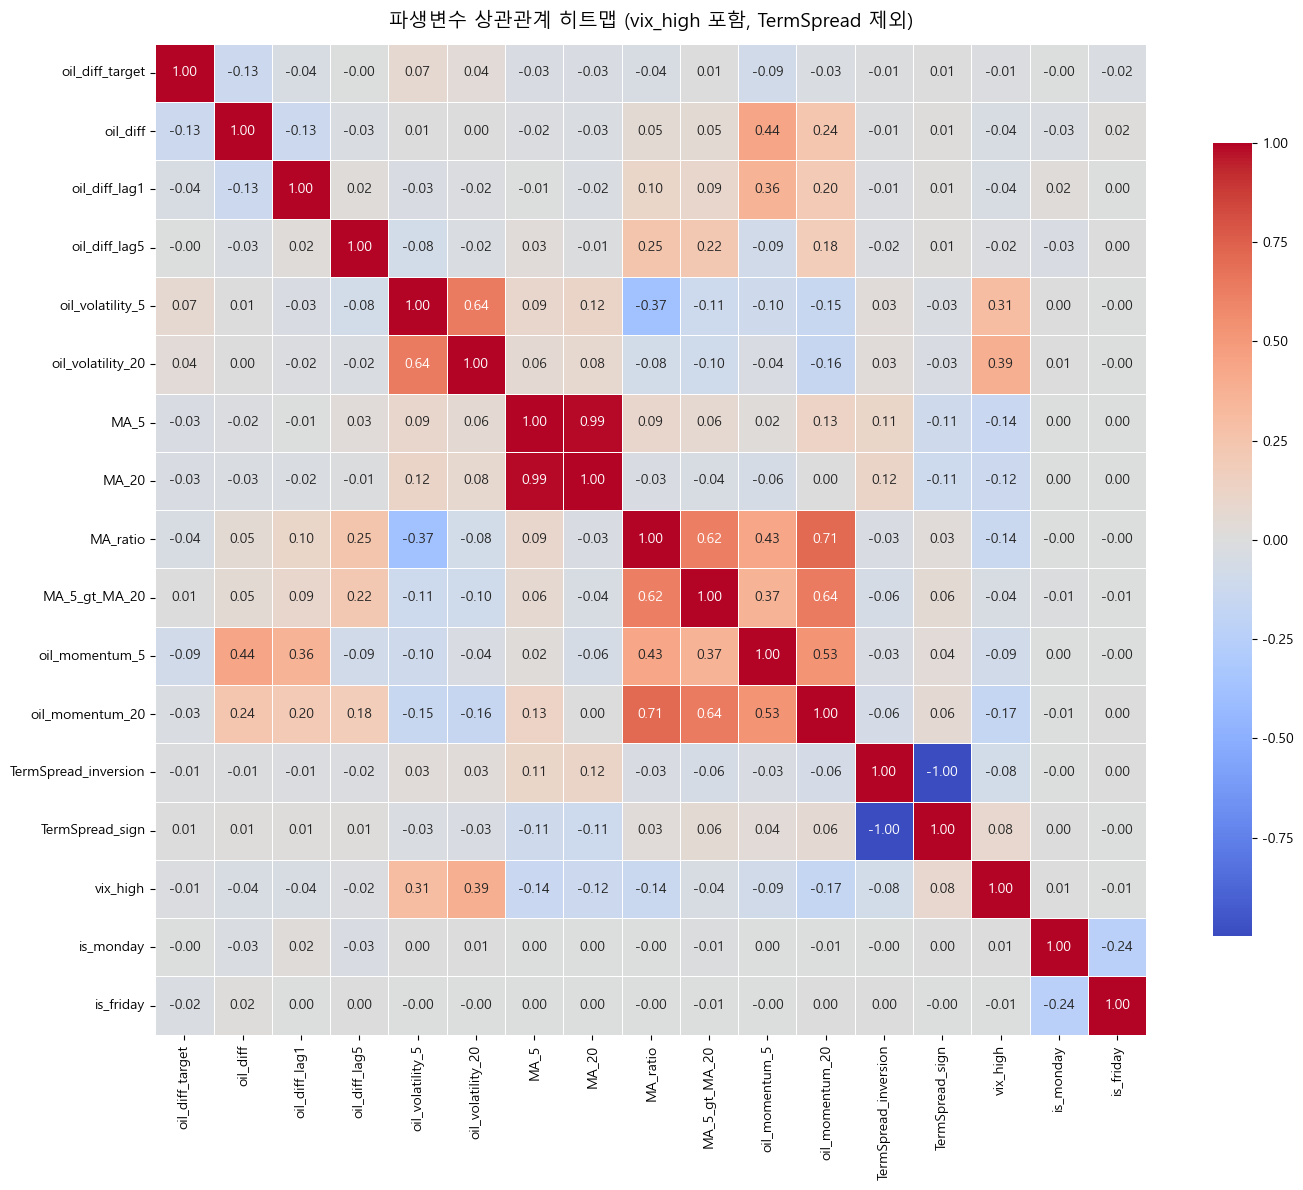


TermSpread_inversion vs sign 상관:
                      TermSpread_inversion  TermSpread_sign
TermSpread_inversion                1.0000          -0.9969
TermSpread_sign                    -0.9969           1.0000


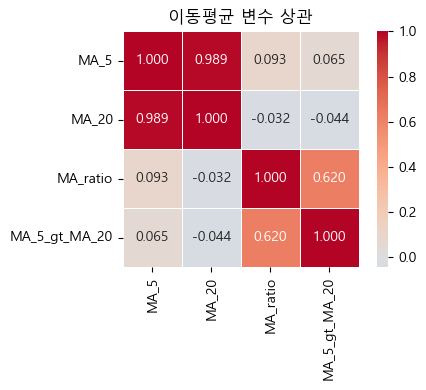


MA 그룹 상관:
                 MA_5   MA_20  MA_ratio  MA_5_gt_MA_20
MA_5           1.0000  0.9894    0.0930         0.0651
MA_20          0.9894  1.0000   -0.0317        -0.0441
MA_ratio       0.0930 -0.0317    1.0000         0.6204
MA_5_gt_MA_20  0.0651 -0.0441    0.6204         1.0000


In [10]:
# ── 전체 파생변수 상관 히트맵 ────────────────────────────
corr_cols = derived_all.columns.tolist()
corr_df   = df_dv[corr_cols].dropna()

plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.8}
)
plt.title('파생변수 상관관계 히트맵 (vix_high 포함, TermSpread 제외)', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# ── 의심 페어 1: TermSpread inversion vs sign ────────────
ts_cols = ['TermSpread_inversion', 'TermSpread_sign']
print('\nTermSpread_inversion vs sign 상관:')
print(df_dv[ts_cols].corr().round(4))

# ── 의심 페어 2: MA 그룹 ─────────────────────────────────
ma_cols = ['MA_5', 'MA_20', 'MA_ratio', 'MA_5_gt_MA_20']
plt.figure(figsize=(5, 4))
sns.heatmap(
    df_dv[ma_cols].dropna().corr(),
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('이동평균 변수 상관', fontsize=12)
plt.tight_layout()
plt.show()
print('\nMA 그룹 상관:')
print(df_dv[ma_cols].corr().round(4))

### 6.9 ADF 검정 (최종 merged 데이터프레임 기준)

**모든 수치형 변수**(이진/sign 제외) 에 대한 ADF 검정.
- p < 0.05 → 정상 (귀무 단위근 기각)
- 비정상 변수는 모델링 시 추가 차분/변환 검토 권장

In [11]:
# ── ADF 검정 (final df_dv 전체) ────────────────────────────
binary_cols = {'MA_5_gt_MA_20', 'TermSpread_inversion', 'TermSpread_sign',
               'vix_high', 'is_monday', 'is_friday'}

def adf_row(s, name):
    s = s.dropna()
    if name in binary_cols or s.nunique() <= 3:
        return {'variable': name, 'ADF stat': np.nan,
                'p-value': np.nan, '5% crit': np.nan,
                'stationary': '-(binary/sign)',
                'recommend': '—'}
    res = adfuller(s, autolag='AIC')
    p = res[1]
    return {
        'variable'  : name,
        'ADF stat'  : res[0],
        'p-value'   : p,
        '5% crit'   : res[4]['5%'],
        'stationary': '✓' if p < 0.05 else '✗',
        'recommend' : '' if p < 0.05 else '추가 차분/변환 권장',
    }

adf_rows = [adf_row(df_dv[c], c) for c in df_dv.columns]
adf_results = pd.DataFrame(adf_rows)
print('=== ADF 검정 결과 (전체) ===')
display(adf_results.round(4))

# 비정상 변수 별도
non_stat = adf_results[adf_results['stationary'] == '✗']
if len(non_stat):
    print('\n[비정상 변수]')
    display(non_stat.round(4))
else:
    print('\n모든 수치형 변수 정상성 확보 ✓')

=== ADF 검정 결과 (전체) ===


,variable,ADF stat,p-value,5% crit,stationary,recommend
0,OilPrice,-10.7205,0.0000,-2.8621,✓,
1,RealInterestRate,-69.2608,0.0000,-2.8621,✓,
2,CPI,-7.9835,0.0000,-2.8621,✓,
3,DollarIndex,-11.1987,0.0000,-2.8621,✓,
4,VIX,-24.0203,0.0000,-2.8621,✓,
5,IndustryProduction,-11.8273,0.0000,-2.8621,✓,
6,CPE,-12.5709,0.0000,-2.8621,✓,
7,OilInventories,-10.7903,0.0000,-2.8621,✓,
8,OPECProduction,-14.7426,0.0000,-2.8621,✓,
9,OilProduction,-14.1019,0.0000,-2.8621,✓,



모든 수치형 변수 정상성 확보 ✓


### 6.9-B `oil_diff` drop + 전체 상관계수 히트맵 ✨추가

- 차분된 `OilPrice` (1st base 차분 결과) 와 `oil_diff` (1st OilPrice.diff()) 는 **수학적으로 완전히 동일**
- VIF 무한대를 유발하므로 **`oil_diff` 를 drop** 하고 진행
  - 정보는 `OilPrice` (차분 후) 에 그대로 보존됨
- drop 후 전체 변수 상관계수 히트맵 + target 과의 상관 Top10 출력

OilPrice vs oil_diff max abs delta: 0.00e+00  (== 0 이면 완전 동일 → drop 가능)
\ndrop 후 shape: (4800, 28)
drop 후 컬럼 (28개):
['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_target', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'TermSpread_sign', 'vix_high', 'is_monday', 'is_friday']


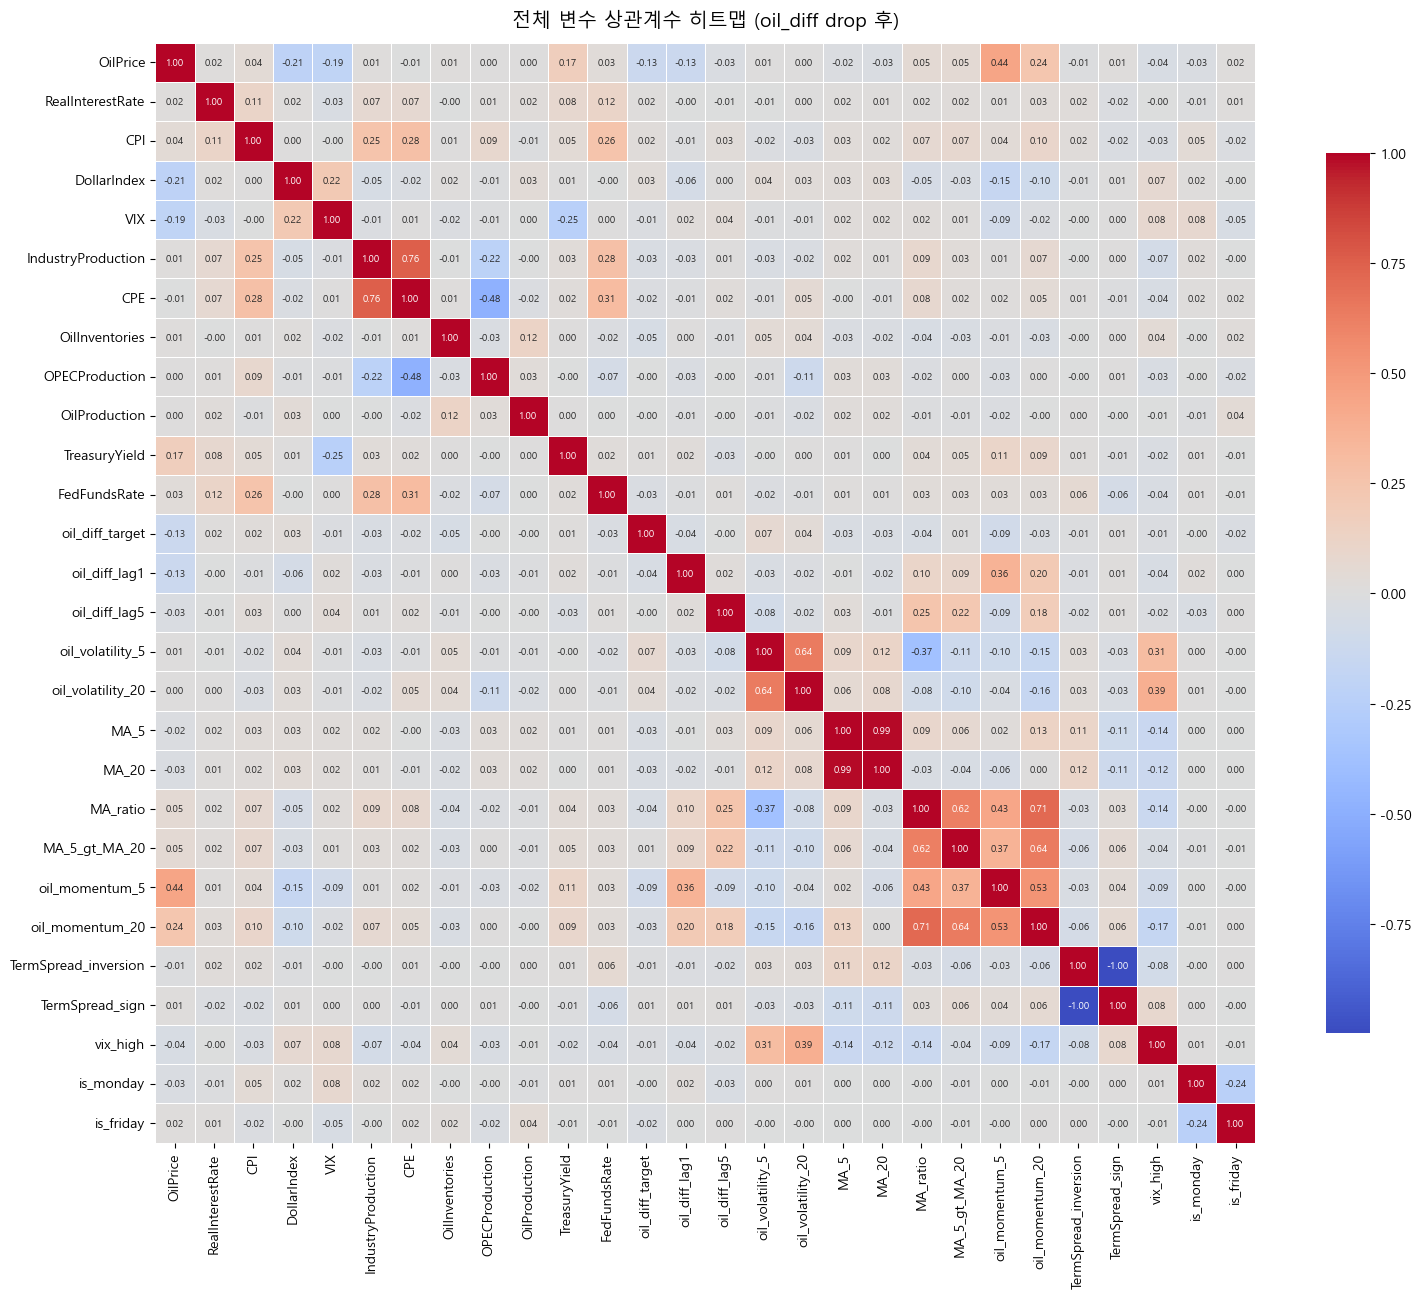

\n[oil_diff_target 과 |corr| 상위 10개]


,variable,corr,|corr|
0,OilPrice,-0.1287,0.1287
1,oil_momentum_5,-0.0891,0.0891
2,oil_volatility_5,0.0656,0.0656
3,OilInventories,-0.0457,0.0457
4,MA_ratio,-0.0405,0.0405
5,oil_diff_lag1,-0.0397,0.0397
6,oil_volatility_20,0.0372,0.0372
7,MA_5,-0.0346,0.0346
8,MA_20,-0.0321,0.0321
9,IndustryProduction,-0.0299,0.0299


In [12]:
# ── Step 1: oil_diff 가 OilPrice 와 동일한지 확인 ─────────
delta = (df_dv['OilPrice'] - df_dv['oil_diff']).abs()
print(f'OilPrice vs oil_diff max abs delta: {delta.max():.2e}  '
      f'(== 0 이면 완전 동일 → drop 가능)')

# ── Step 2: oil_diff 컬럼 drop ────────────────────────────
df_dv = df_dv.drop(columns=['oil_diff'])
print(f'\\ndrop 후 shape: {df_dv.shape}')
print(f'drop 후 컬럼 ({len(df_dv.columns)}개):')
print(df_dv.columns.tolist())

# ── Step 3: 전체 상관계수 히트맵 (target 포함, 전체 컬럼) ──
corr_full = df_dv.dropna().corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_full,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7},
)
plt.title('전체 변수 상관계수 히트맵 (oil_diff drop 후)', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# ── Step 4: target 과의 상관 Top10 (절대값 기준) ──────────
target_corr = corr_full['oil_diff_target'].drop('oil_diff_target')
top = target_corr.abs().sort_values(ascending=False).head(10)
print('\\n[oil_diff_target 과 |corr| 상위 10개]')
display(pd.DataFrame({
    'variable': top.index,
    'corr': target_corr.loc[top.index].round(4),
    '|corr|': top.round(4),
}).reset_index(drop=True))

### 6.10 VIF 다중공선성 (최종 merged)

**연속형 features** (이진/sign/target 제외) 에 대한 VIF 계산.

**기준**: VIF > 10 강한 다공성, > 5 주의

**의심 페어**
- TermSpread_inversion ↔ TermSpread_sign (binary, corr 로 확인)
- MA_5 ↔ MA_20 (둘 다 가격 rolling mean → 강한 상관 예상)

> 참고: `oil_diff` 는 6.9-B 에서 이미 drop 됨 (`OilPrice` 와 동일하여 무한 VIF 회피)

In [13]:
# ── VIF 계산 ───────────────────────────────────────────────
exclude = {'oil_diff_target',                        # target
           'is_monday', 'is_friday', 'vix_high',     # binary
           'TermSpread_inversion', 'TermSpread_sign',
           'MA_5_gt_MA_20'}
vif_features = [c for c in df_dv.columns if c not in exclude]

X = df_dv[vif_features].dropna().copy()
X_with_const = X.assign(_const=1.0)  # statsmodels 권장

vif_df = pd.DataFrame({
    'variable': vif_features,
    'VIF': [variance_inflation_factor(X_with_const.values, i)
            for i in range(len(vif_features))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF (다중공선성) ===')
display(vif_df.round(3))

print('\n[해석] VIF > 10 강한 다공성 / > 5 주의')
hi = vif_df[vif_df['VIF'] > 10]
mid = vif_df[(vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)]
print(f'\nVIF > 10 ({len(hi)}개): {hi["variable"].tolist()}')
print(f'5 < VIF ≤ 10 ({len(mid)}개): {mid["variable"].tolist()}')

=== VIF (다중공선성) ===


,variable,VIF
0,MA_5,460.178
1,MA_20,452.421
2,MA_ratio,5.925
3,oil_momentum_20,4.767
4,CPE,3.404
5,oil_volatility_5,2.767
6,oil_momentum_5,2.562
7,IndustryProduction,2.547
8,oil_volatility_20,2.262
9,OilPrice,1.883



[해석] VIF > 10 강한 다공성 / > 5 주의

VIF > 10 (2개): ['MA_5', 'MA_20']
5 < VIF ≤ 10 (1개): ['MA_ratio']


TermSpread_sign과 TermSpread_inversion 은 상관 -0.99 (역상관) → 의미 중복으로 인해 sign 제거

In [14]:
df_dv = df_dv.drop(columns=['TermSpread_sign'])

### 6.11 CSV 저장

- 저장 경로: `../data/Finance_Final/Derived_Variable_test.csv` (기존 파일 덮어쓰기)
- 학습 직전 `dropna()` 권장 (현재 `oil_diff_target` 마지막 1행 NaN)

In [15]:
SAVE_PATH = '../data/Finance_Final/Derived_Variable.csv'
df_dv.to_csv(SAVE_PATH, index=True)

print(f'저장 완료     : {SAVE_PATH}')
print(f'최종 shape    : {df_dv.shape}')
print(f'기간          : {df_dv.index.min().date()} ~ {df_dv.index.max().date()}')
print(f'전체 컬럼 수  : {df_dv.shape[1]}')
print(f'\n베이스 컬럼 ({len(base_cols_keep)}개): {base_cols_keep}')
print(f'\n파생변수 ({len(derived_all.columns)}개): {derived_all.columns.tolist()}')

print(f'\n참고) dropna 후 shape: {df_dv.dropna().shape}')

저장 완료     : ../data/Finance_Final/Derived_Variable.csv
최종 shape    : (4800, 27)
기간          : 2007-01-31 ~ 2026-03-16
전체 컬럼 수  : 27

베이스 컬럼 (12개): ['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate']

파생변수 (17개): ['oil_diff_target', 'oil_diff', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'TermSpread_sign', 'vix_high', 'is_monday', 'is_friday']

참고) dropna 후 shape: (4799, 27)
